<a href="https://colab.research.google.com/github/Skye-Zhangg/Homework/blob/main/hw5_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Task 2 (15 points):

Part 1 (7 points): Variational Autoencoder (VAE): Here is a complete implementation of
a VAE in TensorFlow: https://www.tensorflow.org/tutorials/generative/cvae
PyTorch implementation is fine too.
Following these steps try generating images using the same encoder-decoder
architecture using a different Image dataset (other than MNIST).

In [1]:
!pip3 install torchvision

In [2]:
import kagglehub
# load dataset
path = kagglehub.dataset_download("puneet6060/intel-image-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'intel-image-classification' dataset.
Path to dataset files: /kaggle/input/intel-image-classification


In [9]:
import os
import kagglehub
import torch
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder

# 1. download dataset


train_dir = os.path.join(path, 'seg_train', 'seg_train')

# 2. transform
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

# 3. dataset
train_dataset = ImageFolder(root=train_dir, transform=transform)

# 4. dataloader
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

print("Classes:", train_dataset.classes)

Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [10]:
def vae_loss(recon_x, x, mu, logvar):
    # reconstruction loss
    recon_loss = nn.functional.mse_loss(recon_x, x, reduction='sum')

    # KL divergence
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return recon_loss + kl_loss

In [11]:
import torch
from torch import nn
import torch.nn.functional as F

class VAE(nn.Module):
    def __init__(self, latent_dim=64):
        super(VAE, self).__init__()

        self.latent_dim = latent_dim

        # -------- Encoder --------
        self.conv1 = nn.Conv2d(3, 32, 4, 2, 1)   # 32x32 → 16x16
        self.conv2 = nn.Conv2d(32, 64, 4, 2, 1)  # 16x16 → 8x8
        self.conv3 = nn.Conv2d(64, 128, 4, 2, 1) # 8x8 → 4x4

        self.fc_mu = nn.Linear(128*4*4, latent_dim)
        self.fc_logvar = nn.Linear(128*4*4, latent_dim)

        # -------- Decoder --------
        self.fc_dec = nn.Linear(latent_dim, 128*4*4)

        self.deconv1 = nn.ConvTranspose2d(128, 64, 4, 2, 1)
        self.deconv2 = nn.ConvTranspose2d(64, 32, 4, 2, 1)
        self.deconv3 = nn.ConvTranspose2d(32, 3, 4, 2, 1)

    def encode(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = x.view(x.size(0), -1)

        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        x = self.fc_dec(z)
        x = x.view(-1, 128, 4, 4)

        x = F.relu(self.deconv1(x))
        x = F.relu(self.deconv2(x))
        x = torch.sigmoid(self.deconv3(x))

        return x

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar

In [15]:
import torch.nn.functional as F
import torch.optim as optim

def loss_function(recon_x, x, mu, logvar):
    # reconstruction loss
    recon_loss = F.mse_loss(recon_x, x, reduction='sum')

    # KL divergence
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return recon_loss + kl_loss

# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

vae = VAE().to(device)
optimizer = optim.Adam(vae.parameters(), lr=1e-3)
# training
def train():
    vae.train()
    total_loss = 0

    for data, _ in train_loader:
        data = data.to(device)

        optimizer.zero_grad()

        recon_batch, mu, logvar = vae(data)
        loss = loss_function(recon_batch, data, mu, logvar)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader.dataset)
    print(f"Train Loss: {avg_loss:.4f}")

# run training
epochs = 10
for epoch in range(epochs):
    print(f"Epoch {epoch+1}")
    train()

Epoch 1
Train Loss: 813.3109
Epoch 2
Train Loss: 663.0057
Epoch 3
Train Loss: 640.2326
Epoch 4
Train Loss: 619.3764
Epoch 5
Train Loss: 605.6970
Epoch 6
Train Loss: 597.0686
Epoch 7
Train Loss: 591.4729
Epoch 8
Train Loss: 588.3541
Epoch 9
Train Loss: 585.8917
Epoch 10
Train Loss: 584.3948


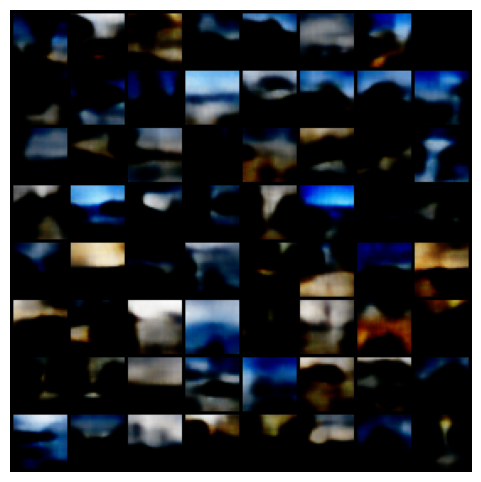

In [14]:
import torchvision
import matplotlib.pyplot as plt

vae.eval()
with torch.no_grad():
    z = torch.randn(64, vae.latent_dim).to(device)

    # decode
    sample = vae.decode(z).cpu()

    sample = torch.clamp(sample, 0, 1)

    grid_img = torchvision.utils.make_grid(sample, nrow=8)

    plt.figure(figsize=(6,6))
    plt.imshow(grid_img.permute(1, 2, 0))
    plt.axis('off')
    plt.show()

Part 2 (8 points): Generative Adversarial Networks (GANs): Repeat part 1 (use same
dataset) and implement a GAN model to generate high quality synthetic images. You
may follow steps outlined here: https://www.tensorflow.org/tutorials/generative/dcgan

The generated images show meaningful structures such as sky, water, and forest-like textures, indicating that the GAN has learned the underlying data distribution.

However, the generated images are still somewhat blurry and lack fine details. This is likely due to limited training epochs and the complexity of the dataset. Increasing training time or using more advanced GAN architectures could further improve image quality.

Overall, the model demonstrates the ability of GANs to generate realistic scene-like images from random noise.

Using Colab cache for faster access to the 'intel-image-classification' dataset.
Epoch [1/20]  D_loss: 1.5863  G_loss: 2.0450
Epoch [2/20]  D_loss: 1.0186  G_loss: 1.5043
Epoch [3/20]  D_loss: 0.5376  G_loss: 4.3089
Epoch [4/20]  D_loss: 0.5258  G_loss: 2.3192
Epoch [5/20]  D_loss: 0.3779  G_loss: 2.8480
Epoch [6/20]  D_loss: 0.3257  G_loss: 3.4467
Epoch [7/20]  D_loss: 1.0999  G_loss: 3.5962
Epoch [8/20]  D_loss: 0.3979  G_loss: 5.9975
Epoch [9/20]  D_loss: 0.3712  G_loss: 4.5491
Epoch [10/20]  D_loss: 0.2052  G_loss: 5.4642
Epoch [11/20]  D_loss: 0.4289  G_loss: 2.6647
Epoch [12/20]  D_loss: 0.4704  G_loss: 3.5941
Epoch [13/20]  D_loss: 0.5719  G_loss: 4.1622
Epoch [14/20]  D_loss: 1.0648  G_loss: 7.6133
Epoch [15/20]  D_loss: 0.2985  G_loss: 4.9306
Epoch [16/20]  D_loss: 0.4681  G_loss: 3.4811
Epoch [17/20]  D_loss: 0.4451  G_loss: 2.5208
Epoch [18/20]  D_loss: 0.2361  G_loss: 3.5149
Epoch [19/20]  D_loss: 0.5636  G_loss: 5.2265
Epoch [20/20]  D_loss: 0.5007  G_loss: 4.3500


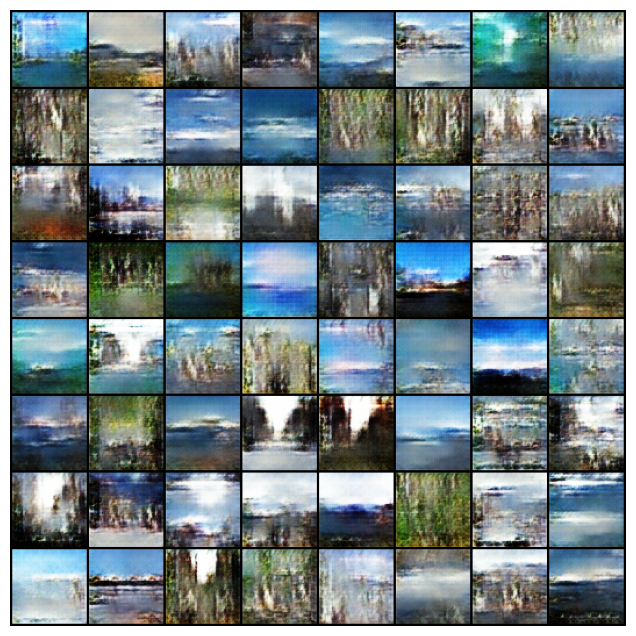

In [1]:
import os
import kagglehub
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

#Load dataset
path = kagglehub.dataset_download("puneet6060/intel-image-classification")

train_dir = os.path.join(path, 'seg_train', 'seg_train')

# Data preprocessing
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = datasets.ImageFolder(train_dir, transform=transform)

dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=128,
    shuffle=True
)


# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Generator
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(100, 512, 4, 1, 0),
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            nn.ConvTranspose2d(512, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 3, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, x):
        return self.main(x)

# Discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),
            nn.LeakyReLU(0.2, True),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, True),

            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, True),

            nn.Conv2d(256, 512, 4, 2, 1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, True),

            nn.Conv2d(512, 1, 4, 1, 0),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.main(x).view(-1, 1)


# Initialize models
generator = Generator().to(device)
discriminator = Discriminator().to(device)

criterion = nn.BCELoss()

optimizer_g = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_d = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

# Training
epochs = 20
for epoch in range(epochs):
    for i, (real_images, _) in enumerate(dataloader):
        batch_size = real_images.size(0)
        real_images = real_images.to(device)

        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # ---- Train Discriminator ----
        optimizer_d.zero_grad()

        outputs = discriminator(real_images)
        d_loss_real = criterion(outputs, real_labels)

        z = torch.randn(batch_size, 100, 1, 1).to(device)
        fake_images = generator(z)

        outputs = discriminator(fake_images.detach())
        d_loss_fake = criterion(outputs, fake_labels)

        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()
        optimizer_d.step()

        # ---- Train Generator ----
        optimizer_g.zero_grad()

        z = torch.randn(batch_size, 100, 1, 1).to(device)
        fake_images = generator(z)

        outputs = discriminator(fake_images)
        g_loss = criterion(outputs, real_labels)

        g_loss.backward()
        optimizer_g.step()

    print(f"Epoch [{epoch+1}/{epochs}]  D_loss: {d_loss.item():.4f}  G_loss: {g_loss.item():.4f}")

# Generate images
generator.eval()
with torch.no_grad():
    z = torch.randn(64, 100, 1, 1).to(device)
    fake_images = generator(z).cpu()
    fake_images = (fake_images + 1) / 2  # [-1,1] → [0,1]

    grid = torchvision.utils.make_grid(fake_images, nrow=8)
    plt.figure(figsize=(8,8))
    plt.imshow(grid.permute(1,2,0))
    plt.axis('off')
    plt.show()